# Graph Laplacian and Spectral Graph Theory

Graph Laplacians are a core bridge between geometry, probability, and learning:
they encode smoothness on graphs, define graph Fourier modes, and appear as precision operators in Gaussian Markov models.
This notebook explores these roles from one computational pipeline.

For weighted adjacency $W$ and degree matrix $D$, the graph Laplacian $L=D-W$ satisfies
$$x^\top Lx=\frac12\sum_{i,j}w_{ij}(x_i-x_j)^2.$$
Thus low-frequency eigenvectors vary slowly across strongly connected vertices. The experiments connect this quadratic energy to graph geometry, diffusion, and spectral coordinates.


## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, csr_matrix
from scipy.sparse.linalg import eigsh
from sklearn.neighbors import kneighbors_graph
from ipywidgets import interact, IntSlider, FloatLogSlider

plt.rcParams['figure.dpi'] = 120

## k-NN graph and Laplacian

We build a $k$-nearest-neighbour graph on 2D data and compute the Laplacian spectrum.

Graph: 80 nodes, 320 edges


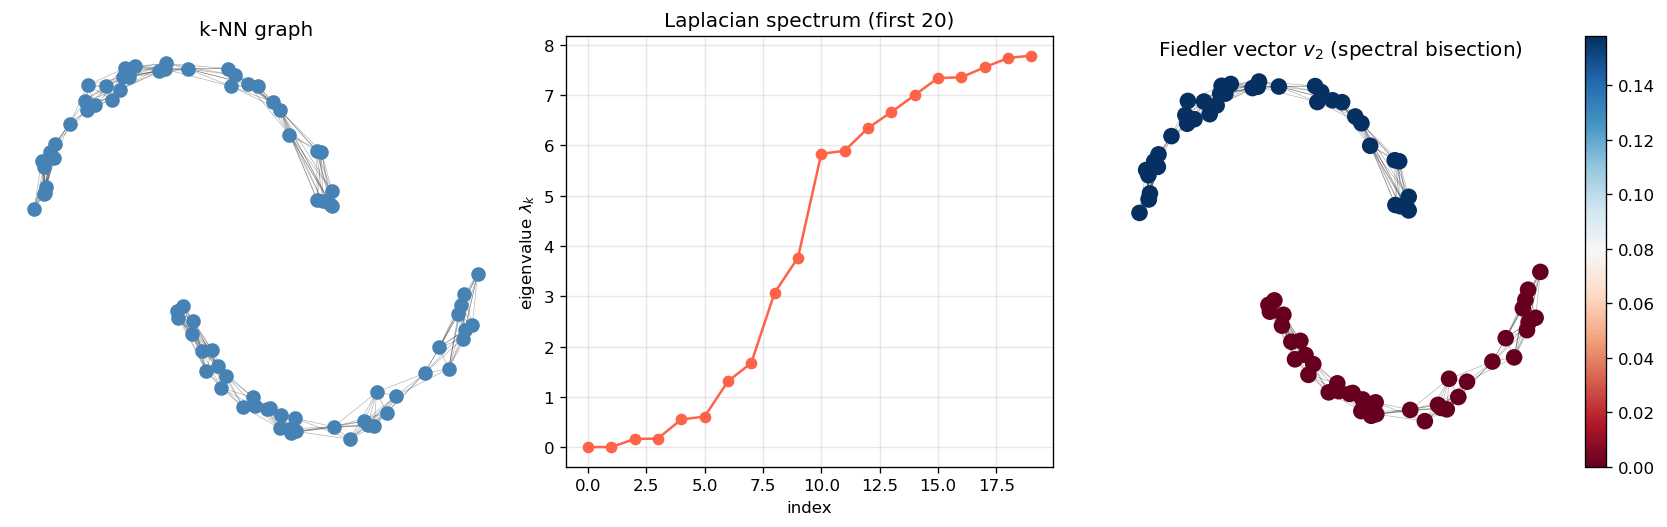

In [2]:
rng = np.random.default_rng(0)
# Two-moon dataset
n = 80
theta1 = rng.uniform(0, np.pi, n//2)
theta2 = rng.uniform(np.pi, 2*np.pi, n//2)
pts = np.vstack([
    np.column_stack([np.cos(theta1), np.sin(theta1)]),
    np.column_stack([np.cos(theta2) + 1, np.sin(theta2) - 0.5]),
])
pts += 0.05 * rng.standard_normal(pts.shape)

k_nn = 8
A = kneighbors_graph(pts, k_nn, mode='connectivity', include_self=False)
W = (A + A.T).toarray() / 2   # symmetrize
np.fill_diagonal(W, 0)
d = W.sum(axis=1)
D = np.diag(d)
L = D - W
print(f'Graph: {len(pts)} nodes, {int(W.sum()/2)} edges')

# Spectrum
eigenvalues, eigenvectors = np.linalg.eigh(L)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Graph
axes[0].scatter(pts[:,0], pts[:,1], c='steelblue', s=60, zorder=5)
for i in range(n):
    for j in range(i+1, n):
        if W[i,j] > 0:
            axes[0].plot(pts[[i,j],0], pts[[i,j],1], 'k-', lw=0.4, alpha=0.3)
axes[0].set_aspect('equal'); axes[0].axis('off'); axes[0].set_title('k-NN graph')

# Spectrum
axes[1].plot(eigenvalues[:20], 'o-', color='tomato', ms=6)
axes[1].set_xlabel('index'); axes[1].set_ylabel('eigenvalue $\\lambda_k$')
axes[1].set_title('Laplacian spectrum (first 20)'); axes[1].grid(alpha=0.3)

# Fiedler vector (2nd eigenvector)
fiedler = eigenvectors[:, 1]
col_map = plt.cm.RdBu(0.5 + fiedler / (2*np.abs(fiedler).max()))
for i in range(n):
    for j in range(i+1, n):
        if W[i,j] > 0:
            axes[2].plot(pts[[i,j],0], pts[[i,j],1], 'k-', lw=0.4, alpha=0.3)
sc = axes[2].scatter(pts[:,0], pts[:,1], c=fiedler, cmap='RdBu', s=80, zorder=5)
plt.colorbar(sc, ax=axes[2], fraction=0.046)
axes[2].set_aspect('equal'); axes[2].axis('off')
axes[2].set_title('Fiedler vector $v_2$ (spectral bisection)')

plt.tight_layout(); plt.show()

## Laplacian as inverse covariance

The regularised Laplacian $\Sigma^{-1} = L + \lambda I$ defines a Gaussian Markov random field. We draw samples and visualise the spatial correlation structure.

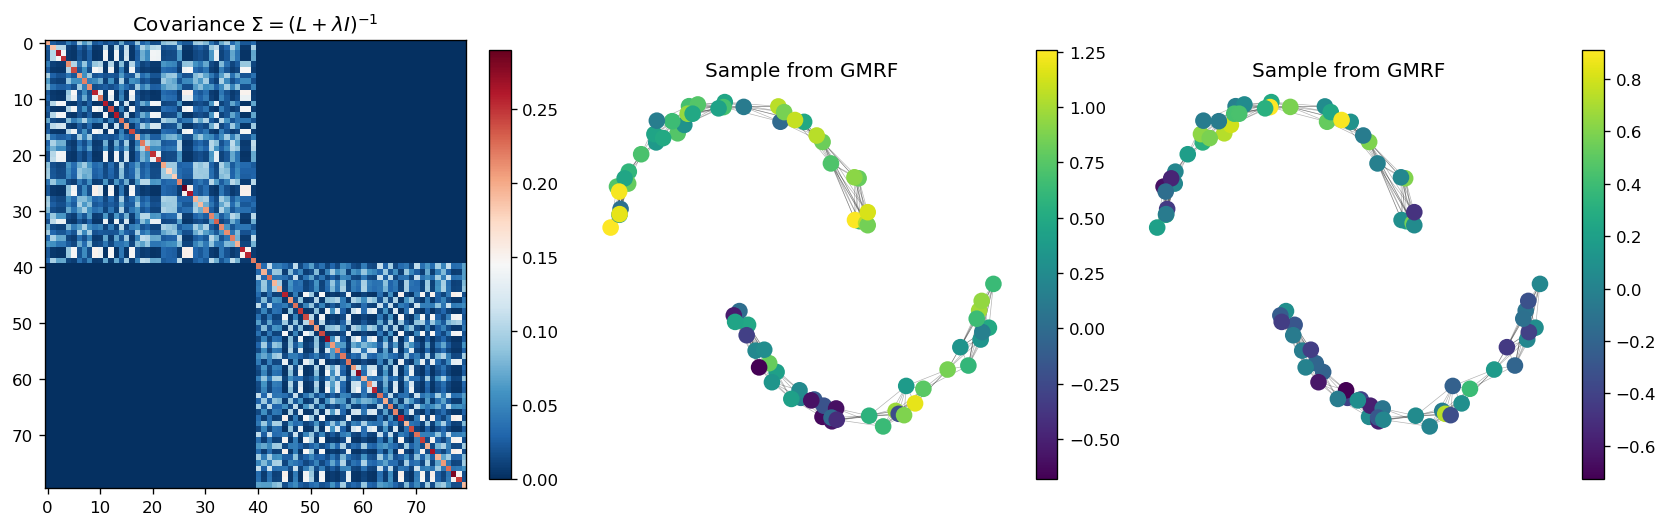

In [3]:
lam = 0.5
Sigma = np.linalg.inv(L + lam * np.eye(n))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Covariance matrix
im = axes[0].imshow(Sigma, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=axes[0], fraction=0.046)
axes[0].set_title('Covariance $\\Sigma = (L+\\lambda I)^{-1}$')

# Draw samples
samples = rng.multivariate_normal(np.zeros(n), Sigma, 3)
for ax, s in zip(axes[1:], samples[:2]):
    for i in range(n):
        for j in range(i+1, n):
            if W[i,j] > 0:
                ax.plot(pts[[i,j],0], pts[[i,j],1], 'k-', lw=0.4, alpha=0.3)
    sc = ax.scatter(pts[:,0], pts[:,1], c=s, cmap='viridis', s=80, zorder=5)
    plt.colorbar(sc, ax=ax, fraction=0.046)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title('Sample from GMRF')

plt.tight_layout(); plt.show()

## Spectral clustering

Using the $k$ smallest eigenvectors of $\mathcal{L}$ as node features, then $k$-means yields the spectral clustering partition.

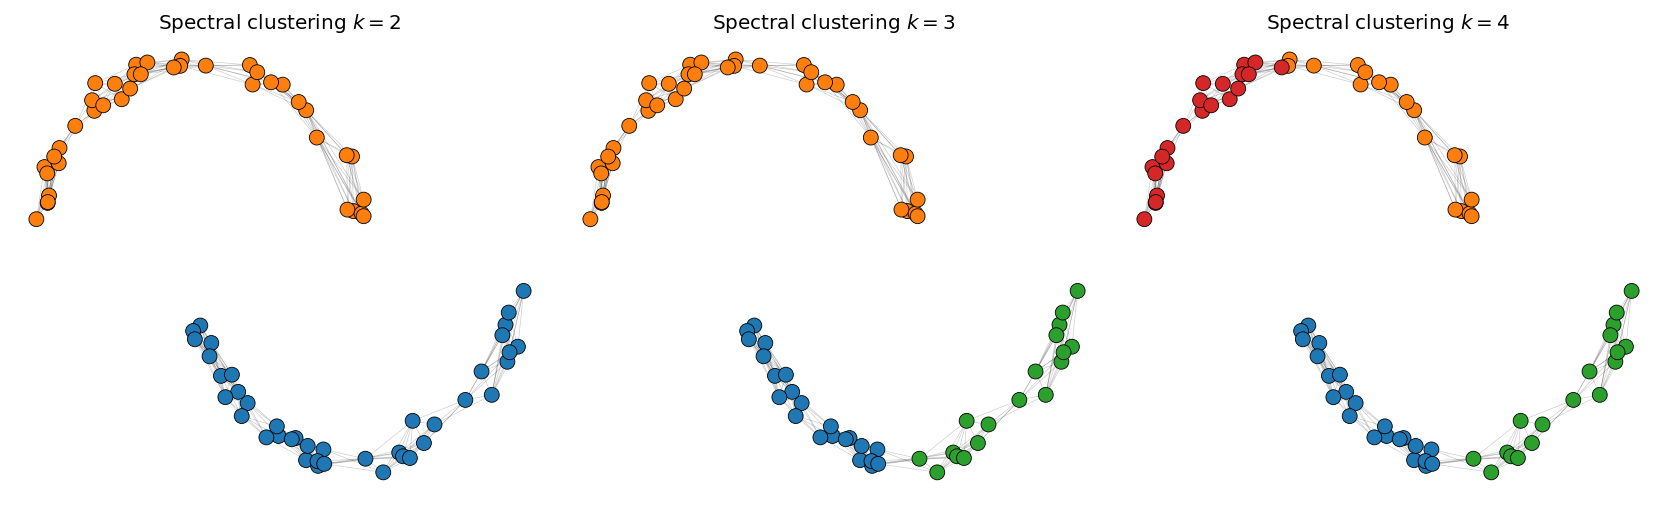

In [4]:
from sklearn.cluster import KMeans

# Normalized Laplacian
d_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(d, 1e-12)))
L_norm = d_inv_sqrt @ L @ d_inv_sqrt
evals_n, evecs_n = np.linalg.eigh(L_norm)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, k_clust in zip(axes, [2, 3, 4]):
    U = evecs_n[:, :k_clust]
    U_norm = U / (np.linalg.norm(U, axis=1, keepdims=True) + 1e-12)
    labels = KMeans(n_clusters=k_clust, n_init=10, random_state=0).fit_predict(U_norm)
    cols_k = plt.cm.tab10(labels / 9.0)
    for i in range(n):
        for j in range(i+1, n):
            if W[i,j] > 0:
                ax.plot(pts[[i,j],0], pts[[i,j],1], 'k-', lw=0.4, alpha=0.2)
    ax.scatter(pts[:,0], pts[:,1], c=cols_k, s=80, edgecolors='k', linewidths=0.5, zorder=5)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(f'Spectral clustering $k={k_clust}$')

plt.tight_layout(); plt.show()

## Interactive: regularisation $\lambda$

## Bibliographical resources

- Chung, F. R. K. (1997). *Spectral Graph Theory*. American Mathematical Society.
- von Luxburg, U. (2007). A tutorial on spectral clustering. *Statistics and Computing*, 17(4), 395–416.
- Ng, A. Y., Jordan, M. I. and Weiss, Y. (2002). On spectral clustering: Analysis and an algorithm. *Advances in Neural Information Processing Systems*, 14.
- Belkin, M. and Niyogi, P. (2003). Laplacian eigenmaps for dimensionality reduction. *Neural Computation*, 15(6), 1373–1396.
- Mohar, B. (1991). The Laplacian spectrum of graphs. In *Graph Theory, Combinatorics, and Applications* (pp. 871–898). Wiley.